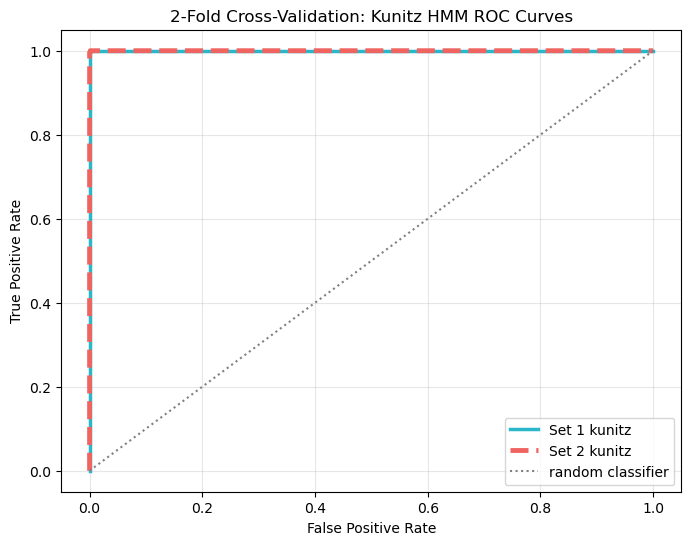

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def get_roc_data(filename):
    df = pd.read_csv(filename, sep='\t', header=None, names=['id', 'evalue', 'label'])
    # Transform e-values: smaller is better, so use -log10
    scores = -np.log10(df['evalue'] + 1e-200)
    fpr, tpr, _ = roc_curve(df['label'], scores)
    return fpr, tpr, auc(fpr, tpr)

# Calculate for both sets
fpr1, tpr1, auc1 = get_roc_data('kunitz_set_1.txt')
fpr2, tpr2, auc2 = get_roc_data('kunitz_set_2.txt')

# Plotting both on the same figure
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label='Set 1 kunitz', color='#2AB7CA', linewidth=2.5)
plt.plot(fpr2, tpr2, label='Set 2 kunitz ', color='#EF6461',linewidth=3.5 ,linestyle='--')
plt.plot([0, 1], [0, 1],label="random classifier", color='gray', linestyle=':') # Random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('2-Fold Cross-Validation: Kunitz HMM ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=300)
plt.show()

